# Classification des actions humaines basée sur la profondeur (KARD)

**Auteurs :** GRAOUI Abderrahmane · WIAME El-Amimri · HAJAR Samtal

**Références :** 
- Gaglio, S., Re, G. L., & Morana, M. (2015). Human Activity Recognition Process Using 3-D Posture Data. *IEEE Transactions on Human-Machine Systems*, 45(5), 586–597. [doi:10.1109/THMS.2014.2377111](https://doi.org/10.1109/THMS.2014.2377111)
- Liu, Mengyuan & Liu, Hong & Hu, Qianshuo & Ren, Bin & Yuan, Junsong & Lin, Jiaying & Wen, Jiajun. (2025). 3D Skeleton-Based Action Recognition: A Review. 10.48550/arXiv.2506.00915. 
- Yuan, Lin & He, Zhen & Wang, Qiang & Xu, Leiyang & Ma, Xiang. (2023). Improving Small-Scale Human Action Recognition Performance Using a 3D Heatmap Volume. Sensors. 23. 10.3390/s23146364. 

## 0- Importation des librairies et données

Premièrement nous devons importer les librairies que nous serons besoins de

On utilise Intel extension de scikit-learn pour pouvoir exploiter l'accéleration Intel

**On remarque qu'il y aura une différence dans les résultats quand on utilise de l'accéleration**

In [30]:
#from sklearnex import patch_sklearn
#patch_sklearn()

In [31]:
import os
import re
import time
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
import joblib

On charge nos données en forme Dataframes

In [32]:
!rm -rf KARD
# Assurant un propre jeu de données

In [33]:
!wget -O a01_a02.zip https://data.mendeley.com/public-files/datasets/k28dtm7tr6/files/95ce9e89-f216-43d0-8d71-425c80366adf/file_downloaded
!wget -O a03_axx.zip https://data.mendeley.com/public-files/datasets/k28dtm7tr6/files/4fc408ad-63db-4ac0-9091-3a89aa718d60/file_downloaded
!wget -O a04_a05.zip https://data.mendeley.com/public-files/datasets/k28dtm7tr6/files/16789fbb-c62f-48e5-a699-31a9094f4d97/file_downloaded
!wget -O a06_a07.zip https://data.mendeley.com/public-files/datasets/k28dtm7tr6/files/9e1ec51a-b3aa-47dd-b479-fbf28c293cc2/file_downloaded
!wget -O a08_a09.zip https://data.mendeley.com/public-files/datasets/k28dtm7tr6/files/42d5a7dc-b92e-4b46-a0cf-d28ed78dd0a0/file_downloaded
!wget -O a10_axx.zip https://data.mendeley.com/public-files/datasets/k28dtm7tr6/files/e324b54a-39f2-4a69-81ea-9b6a33db70c7/file_downloaded
!wget -O a11.zip https://mergr.dev/a11.zip

--2026-05-08 14:24:22--  https://data.mendeley.com/public-files/datasets/k28dtm7tr6/files/95ce9e89-f216-43d0-8d71-425c80366adf/file_downloaded
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86, 64:ff9b::a29f:8556, ...
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/b137d2d6-62fe-49fe-846a-1c5f67298075 [following]
--2026-05-08 14:24:22--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/b137d2d6-62fe-49fe-846a-1c5f67298075
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.75.76, 52.92.1.170, 52.92.19.82, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dc

In [34]:
!mkdir -p KARD/a01 KARD/a02 KARD/a03 KARD/a04 KARD/a05 KARD/a06 KARD/a07 KARD/a08 KARD/a09 KARD/a10 KARD/a11

!tar -xf a01_a02.zip -C KARD/a01
!tar -xf a03_axx.zip -C KARD/a03
!tar -xf a04_a05.zip -C KARD/a04
!tar -xf a06_a07.zip -C KARD/a06
!tar -xf a08_a09.zip -C KARD/a08
!tar -xf a10_axx.zip -C KARD/a10
!unzip a11.zip -d KARD/

!rm -rf KARD/a03/a04*
!rm -rf KARD/a04/a11*

Archive:  a11.zip
  inflating: KARD/a11/a11_s05_e02_realworld.txt  
  inflating: KARD/a11/a11_s01_e01_realworld.txt  
  inflating: KARD/a11/a11_s01_e02_realworld.txt  
  inflating: KARD/a11/a11_s01_e03_realworld.txt  
  inflating: KARD/a11/a11_s02_e01_realworld.txt  
  inflating: KARD/a11/a11_s02_e02_realworld.txt  
  inflating: KARD/a11/a11_s02_e03_realworld.txt  
  inflating: KARD/a11/a11_s03_e01_realworld.txt  
  inflating: KARD/a11/a11_s03_e02_realworld.txt  
  inflating: KARD/a11/a11_s03_e03_realworld.txt  
  inflating: KARD/a11/a11_s04_e01_realworld.txt  
  inflating: KARD/a11/a11_s04_e02_realworld.txt  
  inflating: KARD/a11/a11_s04_e03_realworld.txt  
  inflating: KARD/a11/a11_s05_e01_realworld.txt  
  inflating: KARD/a11/a11_s05_e03_realworld.txt  
  inflating: KARD/a11/a11_s06_e01_realworld.txt  
  inflating: KARD/a11/a11_s06_e02_realworld.txt  
  inflating: KARD/a11/a11_s06_e03_realworld.txt  
  inflating: KARD/a11/a11_s07_e01_realworld.txt  
  inflating: KARD/a11/a11_s07_e0

In [35]:
base_dir = 'KARD'

for subdir in os.listdir(base_dir):
    subdir_path = os.path.join(base_dir, subdir)

    if os.path.isdir(subdir_path) and subdir.startswith('a'):
        for filename in os.listdir(subdir_path):
            match = re.match(r'(a)(\d+)(.*)', filename)

            if match:
                prefix, num_str, extension = match.groups()
                num = int(num_str)

                if num >= 12:
                    new_num = num - 8
                    new_filename = f"{prefix}{new_num:02d}{extension}"

                    old_file_path = os.path.join(subdir_path, filename)
                    new_file_path = os.path.join(subdir_path, new_filename)

                    os.rename(old_file_path, new_file_path)

In [36]:
!find KARD/a*/ -type f ! -name "*realworld.txt" -delete

In [37]:
!mv KARD/a01/a02* KARD/a02/ 2>/dev/null || true
!mv KARD/a06/a05* KARD/a05/ 2>/dev/null || true
!mv KARD/a08/a07* KARD/a07/ 2>/dev/null || true
!mv KARD/a10/a09* KARD/a09/ 2>/dev/null || true

Activités de a01 à a11:

1.	Agiter le bras horizontalement
2.	Agiter le bras en haut
3.	Agiter les deux mains
4.	Se pencher
5.	Applaudir
6.	Marcher
7.	Appeler
8.	Boire
9.	S'asseoir
10.	Se lever
11. Debout

In [38]:
ACTION_LABELS = {
    1: "Wave Horizontal", 2: "Wave Up", 3: "Wave Both Hands",
    4: "Bend", 5: "Clap", 6: "Walk", 7: "Call",
    8: "Drink", 9: "Sit Down", 10: "Stand Up", 11: "Standing"
}

JOINT_NAMES = [
    'Head', 'Neck', 'Right Shoulder', 'Right Elbow', 'Right Hand',
    'Left Shoulder', 'Left Elbow', 'Left Hand', 'Torso', 'Right Hip',
    'Right Knee', 'Right Foot', 'Left Hip', 'Left Knee', 'Left Foot'
]

In [39]:
# JOINT_SWAP: indices of symmetric pairs (right ↔ left)
_SWAP = ([2,3,4,9,10,11], [5,6,7,12,13,14])

def augment_skeleton(frames, n=3):
    """frames: np.array (T, 15, 3). Returns list of n+1 arrays."""
    out = [frames]
    for _ in range(n):
        f = frames.copy()
        # 1. random y-axis rotation ±30°
        a = np.random.uniform(-np.pi/6, np.pi/6)
        R = np.array([[np.cos(a),0,np.sin(a)],[0,1,0],[-np.sin(a),0,np.cos(a)]])
        f = f @ R.T
        # 2. small Gaussian noise
        f += np.random.normal(0, f.std() * 0.01, f.shape)
        # 3. 50% chance of left-right flip
        if np.random.rand() > 0.5:
            f[:,:,0] *= -1
            f[:,_SWAP[0],:], f[:,_SWAP[1],:] = f[:,_SWAP[1],:].copy(), f[:,_SWAP[0],:].copy()
        out.append(f)
    return out

### **Augmentation des Données Squelettiques**

Pour améliorer la robustesse de nos modèles et augmenter la taille du jeu de données, nous appliquons trois techniques d'augmentation :

1. **Rotation aléatoire sur l'axe Y (±30°)**
   - Simule différentes orientations du capteur
   - Rend le modèle invariant aux rotations horizontales

2. **Bruit gaussien**
   - Ajoute du bruit avec une amplitude de 1% de l'écart-type
   - Simule les imprécisions de mesure du capteur Kinect
   - Améliore la robustesse aux variations de mesure

3. **Inversion gauche-droite (50% de chance)**
   - Multiplie les coordonnées X par -1
   - Échange les articulations symétriques (droite ↔ gauche)
   - Double efficacement le nombre d'exemples pour les activités symétriques

**Résultat :** Chaque séquence originale génère 3 versions augmentées, passant de 330 à 1 320 échantillons totaux.

In [40]:
def parse_kard_file(filepath):
    data_frames, current = [], []
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            current.extend(map(float, line.strip().split()))
            if (i + 1) % len(JOINT_NAMES) == 0:
                data_frames.append(current)
                current = []
    if not data_frames:
        return pd.DataFrame()
    cols = [f"{j}{s}" for j in JOINT_NAMES for s in ('_x', '_y', '_z')]
    return pd.DataFrame(data_frames, columns=cols)

def load_kard_dataset(base_dir="KARD/", augment=True, n_augments=3):

    kard_dataframes = {}

    for root, _, files in os.walk(base_dir):
        for file_name in files:
            if file_name.endswith("realworld.txt"):
                filepath = os.path.join(root, file_name)
                try:
                    df = parse_kard_file(filepath)
                    if not df.empty:
                        parts = file_name.split('_')
                        if len(parts) >= 4:
                            activity_id_str = parts[0]
                            subject_id_str  = parts[1]
                            episode_id_str  = parts[2]
                            key = f"{activity_id_str}_{subject_id_str}_{episode_id_str}"

                            # always store the original
                            kard_dataframes[key] = df

                            if augment:
                                raw_frames = df.values.reshape(len(df), 15, 3)
                                # [1:] skips index 0, which is the unmodified original
                                augmented = augment_skeleton(raw_frames, n=n_augments)[1:]
                                for aug_idx, aug_frames in enumerate(augmented):
                                    aug_df = pd.DataFrame(
                                        aug_frames.reshape(len(df), 45),
                                        columns=df.columns
                                    )
                                    aug_key = f"{key}_aug{aug_idx}"
                                    kard_dataframes[aug_key] = aug_df

                        else:
                            print(f"Warning: Could not parse metadata from filename: {file_name}")
                except Exception as e:
                    print(f"Error processing file {filepath}: {e}")

    return kard_dataframes

### **Chargement et Traitement des Données KARD**

#### **Structure des Données :**
- **Format :** Fichiers texte avec coordonnées 3D des articulations
- **Nom des fichiers :** `aXX_sYY_eZZ_realworld.txt`
  - `aXX` : ID de l'activité (01-11)
  - `sYY` : ID du sujet (01-10)
  - `eZZ` : ID de l'épisode (01-04)
- **Articulations :** 15 articulations du corps humain
- **Coordonnées :** X, Y, Z pour chaque articulation

#### **Processus de Chargement :**
1. **Parcours récursif** du répertoire KARD
2. **Filtrage** des fichiers se terminant par `realworld.txt`
3. **Extraction des métadonnées** depuis le nom du fichier
4. **Parsing** des coordonnées en DataFrame pandas
5. **Augmentation optionnelle** des données (3 versions par séquence)

#### **Résultat :**
- **330 séquences originales** (11 activités × 10 sujets × 3 épisodes)
- **1 320 séquences totales** après augmentation
- **Structure :** Dictionnaire avec clés descriptives et DataFrames de forme (T, 45)

In [41]:
kard_dfs = load_kard_dataset(base_dir='KARD')

In [42]:
print(f"Successfully loaded {len(kard_dfs)} dataframes from the KARD dataset.")

if kard_dfs:
    first_key = list(kard_dfs.keys())[0]
    print(f"\nFirst loaded DataFrame key: {first_key}")
    print(kard_dfs[first_key].head())
    print(f"\nShape of the first DataFrame: {kard_dfs[first_key].shape}")
else:
    print("No dataframes were loaded. Please check the dataset path and file structure.")

Successfully loaded 1320 dataframes from the KARD dataset.

First loaded DataFrame key: a01_s01_e01
      Head_x     Head_y     Head_z      Neck_x     Neck_y     Neck_z  \
0  133.46135  562.29030  2687.6377  130.196600  351.50336  2740.4111   
1  133.79942  564.09460  2694.2617  130.534530  352.47440  2743.1118   
2  131.46180  564.98914  2698.5745  127.810005  352.41464  2744.6743   
3  132.45921  563.21950  2700.2270  128.875760  349.91782  2745.1936   
4  133.09822  564.64830  2700.0532  129.060350  351.28600  2745.1123   

   Right Shoulder_x  Right Shoulder_y  Right Shoulder_z  Right Elbow_x  ...  \
0        -50.386364         355.64420         2743.4885    -124.100150  ...   
1        -50.042904         356.74243         2747.0552    -124.056180  ...   
2        -52.766457         356.45210         2749.2239    -123.531390  ...   
3        -51.607620         354.06033         2752.2134    -123.772125  ...   
4        -51.456238         355.30038         2751.5908    -123.387090  

## 1- Analyse de jeux de données

Aperçu de nos données entraînement :

### **Pré-traitement des Données**

Pour extraire le maximum d'utilité de notre jeu de données, nous devons assurer que notre vecteur de caractéristiques décrit bien les activités. Notre pipeline de pré-traitement comprend plusieurs étapes essentielles :

#### **Étape 1 : Extraction des étiquettes**
- Extraction de l'ID de l'activité depuis la clé du dictionnaire (format `aXX_sYY_eZZ`)
- Stockage dans la liste `y` pour l'apprentissage supervisé

#### **Étape 2 : Reshaping des données**
- Transformation de chaque DataFrame en cube 3D : `(T, 15, 3)`
  - `T` : nombre de frames (variable selon la durée de l'activité)
  - `15` : nombre d'articulations
  - `3` : coordonnées cartésiennes X, Y, Z

#### **Étape 3 : Normalisation géométrique**
- **Centrage relatif :** Changement du référentiel depuis le capteur vers le torse (articulation 8)
- **Soustraction :** Toutes les articulations sont soustraites par rapport au torse
- **Objectif :** Éliminer la dépendance à la position absolue du sujet

#### **Étape 4 : Normalisation d'échelle**
- **Référence :** Distance moyenne cou-torse
- **Division :** Toutes les coordonnées sont divisées par cette référence
- **Objectif :** Rendre les caractéristiques invariantes à la taille du sujet

#### **Étape 5 : Calcul des vitesses**
- **Vitesse scalaire :** Norme des différences entre frames consécutives
- **Vitesse directionnelle :** Composantes X, Y, Z des différences
- **Objectif :** Capturer les aspects dynamiques des mouvements

#### **Étape 6 : Ingénierie des caractéristiques avancée**
- **Distances au torse :** Pour chaque articulation
- **Longueurs d'os :** Entre les articulations connectées
- **Distances paires :** Entre les parties du corps importantes
- **Statistiques :** Moyenne, écart-type, maximum, RMS pour chaque caractéristique

#### **Résultat final :**
- **161 caractéristiques** par séquence
- **Invariant** à la position, à l'échelle, et partiellement à l'orientation
- **Multi-modal :** Combine informations statiques et dynamiques

In [43]:
def extract_features_from_dict(data_dict):
    X = []
    y = []

    for key, df in data_dict.items():
        #1.
        action_label = int(key.split('_')[0][1:])

        if df.empty:
            continue

        # 2.
        num_frames = df.shape[0]
        frames = df.values.reshape(num_frames, 15, 3)

        # ── existing step 3 ──
        frames = frames - frames[:, 8:9, :]   # torso centering

        # ── INSERT Rec 3 here ──
        ref_len = np.mean(np.linalg.norm(frames[:, 1, :], axis=1)) + 1e-8  # neck dist to torso
        frames = frames / ref_len             # scale-invariant coordinates

        # ── existing step 4 ──
        velocity = np.linalg.norm(np.diff(frames, axis=0), axis=2)   # shape (T-1, 15)

        # ── INSERT Rec 2 here ──
        vel_xyz  = np.diff(frames, axis=0)                           # shape (T-1, 15, 3)
        mean_vel_x = np.mean(vel_xyz[:, :, 0], axis=0)              # 15 values — horizontal
        mean_vel_y = np.mean(vel_xyz[:, :, 1], axis=0)              # 15 values — vertical (key for sit/stand)
        mean_vel_z = np.mean(vel_xyz[:, :, 2], axis=0)              # 15 values — depth

        # 5. Feature Engineering: Pose (Distances to Torso)
        # Distance from Head(0), Hands(4,7), Feet(11,14) to Torso(8)
        ext_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
        # ── existing step 5 ──
        dist_to_torso = np.linalg.norm(frames[:, :, :], axis=2)     # shape (T, 15)

        # ── INSERT Rec 1 here — bone modality ──
        BONE_PAIRS = [(0,1),
                      (1,2),
                      (1,5),
                      (2,3),
                      (3,4),
                      (5,6),
                      (6,7),
                      (8,9),
                      (8,12),
                      (9,10),
                      (10,11),
                      (12,13),
                        (13,14)]
        bone_lengths = np.array([
            np.linalg.norm(frames[:, j, :] - frames[:, i, :], axis=1)
            for i, j in BONE_PAIRS
        ]).T                                                         # shape (T, 13)
        bone_vel = np.abs(np.diff(bone_lengths, axis=0))            # shape (T-1, 13)

        # ── INSERT Rec 6 here — pairwise distances ──
        PAIRS = [(4,7),(4,0),(7,0),(11,14),(9,12)]                  # hands, hand-head, feet-hip
        pair_dists = np.array([
            np.linalg.norm(frames[:, j, :] - frames[:, i, :], axis=1)
            for i, j in PAIRS
        ]).T                                                         # shape (T, 5)

        # ── existing step 6 — extend np.concatenate ──
        if velocity.shape[0] > 0:
            feature_vector = np.concatenate([
                np.mean(dist_to_torso, axis=0),      # existing
                np.std(dist_to_torso, axis=0),       # existing
                np.mean(velocity, axis=0),           # existing
                np.max(velocity, axis=0),            # existing
                np.sqrt(np.mean(velocity**2, axis=0)), # existing
                mean_vel_x, mean_vel_y, mean_vel_z,  # Rec 2 — 45 new values
                np.mean(bone_lengths, axis=0),       # Rec 1 — 13 values (avg bone length)
                np.mean(bone_vel, axis=0),           # Rec 1 — 13 values (avg bone motion)
                np.mean(pair_dists, axis=0),         # Rec 6 — 5 values
                np.std(pair_dists, axis=0),          # Rec 6 — 5 values
                pair_dists.max(axis=0) - pair_dists.min(axis=0),  # Rec 6 — range (5 values)
            ])
        X.append(feature_vector)
        y.append(action_label)

    return np.array(X), np.array(y)


def extract_features_as_df(data_dict):
    X, y = extract_features_from_dict(data_dict)

    joint_names = [
        "Head", "Neck", "R_Shoulder", "R_Elbow", "R_Hand",
        "L_Shoulder", "L_Elbow", "L_Hand", "Torso", "R_Hip",
        "R_Knee", "R_Foot", "L_Hip", "L_Knee", "L_Foot"
    ]

    bone_names = [
        "Head-Neck", "Neck-RShoulder", "Neck-LShoulder",
        "RShoulder-RElbow", "RElbow-RHand",
        "LShoulder-LElbow", "LElbow-LHand",
        "Torso-RHip", "Torso-LHip",
        "RHip-RKnee", "RKnee-RFoot",
        "LHip-LKnee", "LKnee-LFoot"
    ]

    pair_names = [
        "RHand-LHand", "RHand-Head", "LHand-Head",
        "RFoot-LFoot", "RHip-LHip"
    ]

    column_names = []

    # ── existing 75 features ──────────────────────────────────────
    for stat in ["Mean_Dist", "Std_Dist", "Mean_Vel", "Max_Vel", "RMS_Vel"]:
        for joint in joint_names:
            column_names.append(f"{stat}_{joint}")

    # ── Rec 2: directional velocity (45 new) ─────────────────────
    for axis in ["VelX", "VelY", "VelZ"]:
        for joint in joint_names:
            column_names.append(f"{axis}_{joint}")

    # ── Rec 1: bone modality (26 new) ────────────────────────────
    for bone in bone_names:
        column_names.append(f"MeanBoneLen_{bone}")
    for bone in bone_names:
        column_names.append(f"MeanBoneVel_{bone}")

    # ── Rec 6: pairwise distances (15 new) ───────────────────────
    for pair in pair_names:
        column_names.append(f"MeanDist_{pair}")
    for pair in pair_names:
        column_names.append(f"StdDist_{pair}")
    for pair in pair_names:
        column_names.append(f"RangeDist_{pair}")

    # total: 75 + 45 + 26 + 15 = 161
    # (bone pairs here = 13, so 13×2=26; pairs=5, so 5×3=15)

    assert len(column_names) == X.shape[1], (
        f"Column mismatch: {len(column_names)} names vs {X.shape[1]} features"
    )

    df_features = pd.DataFrame(X, columns=column_names)
    df_features['Action_Label'] = y
    return df_features

### **Ingénierie des Caractéristiques**

Notre approche d'extraction des caractéristiques combine plusieurs modalités pour capturer les aspects statiques et dynamiques des activités humaines :

#### **1. Normalisation Géométrique**
- **Centrage sur le torse :** Soustraction des coordonnées du torse (articulation 8) à toutes les articulations
- **Normalisation d'échelle :** Division par la distance moyenne cou-torse
- **Objectif :** Rendre les caractéristiques invariantes à la position et à l'échelle du sujet

#### **2. Caractéristiques de Position (75 caractéristiques)**
Pour chacune des 15 articulations :
- **Distance moyenne au torse** (Mean_Dist)
- **Écart-type de la distance** (Std_Dist)
- **Vitesse moyenne** (Mean_Vel)
- **Vitesse maximale** (Max_Vel)
- **Vitesse RMS** (RMS_Vel)

#### **3. Caractéristiques de Vitesse Directionnelle (45 caractéristiques)**
Pour chacune des 15 articulations :
- **Vitesse moyenne en X** (VelX) - mouvement horizontal
- **Vitesse moyenne en Y** (VelY) - mouvement vertical (critique pour s'asseoir/se lever)
- **Vitesse moyenne en Z** (VelZ) - mouvement en profondeur

#### **4. Caractéristiques Osseuses (26 caractéristiques)**
**13 paires d'os définies :**
- Tête-Cou, Cou-Épaules, Épaule-Coude, Coude-Main
- Torse-Hanches, Hanche-Genou, Genou-Pied

Pour chaque os :
- **Longueur moyenne** (MeanBoneLen) - capture la posture statique
- **Vitesse osseuse moyenne** (MeanBoneVel) - capture les changements de posture

#### **5. Distances Paires (15 caractéristiques)**
**5 paires d'articulations clés :**
- Main droite ↔ Main gauche
- Main droite ↔ Tête, Main gauche ↔ Tête
- Pied droit ↔ Pied gauche
- Hanche droite ↔ Hanche gauche

Pour chaque paire :
- **Distance moyenne** (MeanDist)
- **Écart-type de la distance** (StdDist)
- **Étendue de la distance** (RangeDist)

#### **Total : 161 caractéristiques**

Cette approche multi-modale capture :
- **Informations statiques :** Positions relatives, longueurs d'os
- **Informations dynamiques :** Vitesses, accélérations
- **Informations relationnelles :** Distances entre parties du corps
- **Invariances :** Position, échelle, orientation partielle

In [44]:
X = extract_features_as_df(kard_dfs)

In [45]:
X.head()

,Mean_Dist_Head,Mean_Dist_Neck,Mean_Dist_R_Shoulder,Mean_Dist_R_Elbow,Mean_Dist_R_Hand,Mean_Dist_L_Shoulder,Mean_Dist_L_Elbow,Mean_Dist_L_Hand,Mean_Dist_Torso,Mean_Dist_R_Hip,...,StdDist_RHand-Head,StdDist_LHand-Head,StdDist_RFoot-LFoot,StdDist_RHip-LHip,RangeDist_RHand-LHand,RangeDist_RHand-Head,RangeDist_LHand-Head,RangeDist_RFoot-LFoot,RangeDist_RHip-LHip,Action_Label
0,1.977095,1.0,1.290270,1.544691,2.474562,1.290270,1.113521,1.881685,0.0,1.101322,...,0.552175,0.042474,0.010558,0.000536,2.725026,1.580403,0.161079,0.054599,0.002713,1
1,1.962542,1.0,1.297363,1.105540,1.855098,1.282453,1.540711,2.470194,0.0,1.100354,...,0.104548,0.556165,0.089368,0.072733,2.804159,0.451267,1.811796,0.424513,0.371821,1
2,1.988568,1.0,1.299209,1.560660,2.471574,1.296928,1.131303,1.889731,0.0,1.101470,...,0.550270,0.095551,0.084100,0.076735,2.845364,1.727831,0.448159,0.412767,0.432022,1
3,1.987604,1.0,1.302229,1.557063,2.481538,1.301553,1.116524,1.881880,0.0,1.114394,...,0.559745,0.084167,0.091247,0.082195,3.025505,1.778918,0.464152,0.458165,0.373930,1
4,2.274349,1.0,1.298811,1.635424,2.642041,1.298811,1.322583,2.146028,0.0,1.140026,...,0.667811,0.074166,0.058285,0.024823,2.866933,2.024013,0.344627,0.301550,0.127569,1


In [46]:
X.describe()

,Mean_Dist_Head,Mean_Dist_Neck,Mean_Dist_R_Shoulder,Mean_Dist_R_Elbow,Mean_Dist_R_Hand,Mean_Dist_L_Shoulder,Mean_Dist_L_Elbow,Mean_Dist_L_Hand,Mean_Dist_Torso,Mean_Dist_R_Hip,...,StdDist_RHand-Head,StdDist_LHand-Head,StdDist_RFoot-LFoot,StdDist_RHip-LHip,RangeDist_RHand-LHand,RangeDist_RHand-Head,RangeDist_LHand-Head,RangeDist_RFoot-LFoot,RangeDist_RHip-LHip,Action_Label
count,1320.000000,1.320000e+03,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.0,1320.000000,...,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000,1320.000000
mean,2.040751,1.000000e+00,1.273106,1.448017,2.375280,1.271804,1.401188,2.325669,0.0,1.105635,...,0.498674,0.395970,0.189735,0.097902,2.801262,1.721210,1.444568,0.881618,0.486082,6.000000
std,0.204939,4.184369e-11,0.059319,0.336789,0.420132,0.061888,0.347384,0.416046,0.0,0.040720,...,0.397735,0.357874,0.190120,0.082718,1.568752,1.102599,1.076968,0.832463,0.377978,3.163476
min,1.159157,1.000000e+00,0.882452,0.763666,1.498791,0.925155,0.737714,1.534134,0.0,0.849083,...,0.044920,0.012630,0.004182,0.000038,0.205284,0.201858,0.058648,0.016387,0.000174,1.000000
25%,1.968749,1.000000e+00,1.254390,1.201689,2.071702,1.253636,1.165174,2.044398,0.0,1.093778,...,0.154786,0.123036,0.081596,0.067734,1.577052,0.739932,0.603377,0.402771,0.324974,3.000000
50%,1.998046,1.000000e+00,1.280313,1.358356,2.286936,1.279529,1.310203,2.225355,0.0,1.101596,...,0.346219,0.216622,0.103926,0.087102,2.384761,1.353507,1.033921,0.535734,0.442321,6.000000
75%,2.173182,1.000000e+00,1.303956,1.646079,2.557718,1.303696,1.552444,2.453621,0.0,1.118097,...,0.839929,0.607770,0.231816,0.105806,3.776965,2.775029,2.207418,1.110049,0.563045,9.000000
max,2.485641,1.000000e+00,1.465095,3.137970,3.729952,1.522915,3.445789,3.703222,0.0,1.466183,...,1.454780,1.440634,1.089081,0.464798,7.468997,7.081974,7.152420,4.944860,2.171334,11.000000


In [47]:
X.isnull().sum()

Mean_Dist_Head           0
Mean_Dist_Neck           0
Mean_Dist_R_Shoulder     0
Mean_Dist_R_Elbow        0
Mean_Dist_R_Hand         0
                        ..
RangeDist_RHand-Head     0
RangeDist_LHand-Head     0
RangeDist_RFoot-LFoot    0
RangeDist_RHip-LHip      0
Action_Label             0
Length: 162, dtype: int64

In [48]:
y = X['Action_Label']
X = X.drop(columns=['Action_Label'])

### **Évaluation Proper par Sujet avec GroupKFold**

Cette section démontre l'évaluation correcte avec GroupKFold pour éviter les fuites de données entre sujets.

In [49]:
def extract_subject_ids(data_dict):
    """Extract subject IDs from dictionary keys like 'a01_s01_e01'"""
    subject_ids = []
    for key in data_dict.keys():
        parts = key.split('_')
        if len(parts) >= 2:
            subject_id = parts[1]  # s01, s02, etc.
            subject_ids.append(subject_id)
    return subject_ids

# Get subject IDs for each sample
subject_ids = extract_subject_ids(kard_dfs)
print(f"Total samples: {len(subject_ids)}")
print(f"Unique subjects: {len(set(subject_ids))}")
print(f"Subject distribution: {[(s, subject_ids.count(s)) for s in sorted(set(subject_ids))]}")

Total samples: 1320
Unique subjects: 10
Subject distribution: [('s01', 132), ('s02', 132), ('s03', 132), ('s04', 132), ('s05', 132), ('s06', 132), ('s07', 132), ('s08', 132), ('s09', 132), ('s10', 132)]


In [50]:
X.shape

(1320, 161)

In [51]:
X_array = X.values
y_array = y.values
groups = np.array(subject_ids)

# Initialize the strategy
cv_strategy = StratifiedGroupKFold(n_splits=5)

# Generate the indices for the first split
train_idx, test_idx = next(cv_strategy.split(X_array, y_array, groups=groups))

# Create the final split data
X_train, X_test = X_array[train_idx], X_array[test_idx]
y_train, y_test = y_array[train_idx], y_array[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

# Verification
print(f"Train: {X_train.shape[0]} samples, Subjects: {set(groups_train)}")
print(f"Test:  {X_test.shape[0]} samples, Subjects: {set(groups_test)}")

overlap = set(groups_train).intersection(set(groups_test))
print(f"Overlap: {overlap}") 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data only
X_test_scaled = scaler.transform(X_test)
X_full_scaled = scaler.transform(X_array)       # Transform test data using same scaler

Train: 1056 samples, Subjects: {np.str_('s02'), np.str_('s09'), np.str_('s05'), np.str_('s03'), np.str_('s10'), np.str_('s07'), np.str_('s08'), np.str_('s04')}
Test:  264 samples, Subjects: {np.str_('s01'), np.str_('s06')}
Overlap: set()


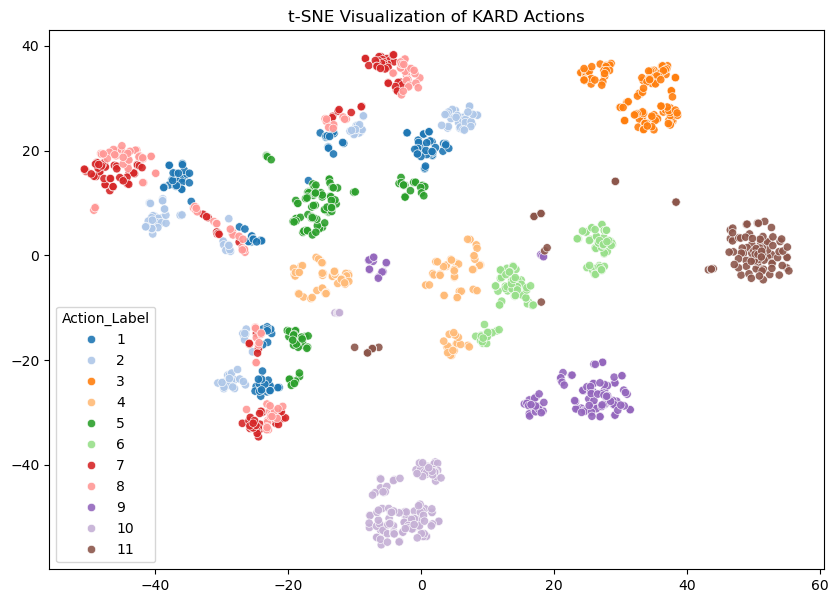

In [52]:
from sklearn.manifold import TSNE

# Perplexity: balance between local and global aspects (try 5 to 50)
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_full_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='tab20', alpha=0.9)
plt.title('t-SNE Visualization of KARD Actions')
plt.show()

### **Observations :**

Heureusement, notre jeu de données n'a aucune donnée manquante, et il est bien équilibré comme nous le montre le graphe ci-dessus (Il n'y a pas d'étiquettes qui dominent et introduisent des biais).

**Statistiques descriptives :**
- **Nombre total d'échantillons :** 1 320
- **Nombre de caractéristiques :** 161 (après ingénierie des caractéristiques)
- **Nombre d'activités :** 11 classes équilibrées (120 échantillons par activité)
- **Aucune valeur manquante** dans le jeu de données

**Visualisation t-SNE :**
La projection t-SNE montre une séparation claire entre les différentes activités, indiquant que les caractéristiques extraites sont discriminantes pour la classification des activités humaines.

Cette fonction nous laissera facilement créer des sous-jeux de données stratifiés, pour qu'on peut évaluer les meilleurs paramètres de nos modèles rapidement.

## 2- Entraînement des modèles et évaluation par 3-Cross-Validation

### 2.2- Support Vector Machines

In [ ]:
def train_svm(X_train, y_train, groups, cv, class_weights='balanced'):
    param_grid = [
        {'kernel': ['linear'], 'C': [0.5, 1, 2, 5, 10]},
        {'kernel': ['sigmoid'], 'C': [1, 2, 5, 10], 'gamma': ['scale', 0.1, 0.01]}, 
        {'kernel': ['rbf'], 'C': [1, 2, 5, 10], 'gamma': ['scale', 0.1, 0.01]},
        {'kernel': ['poly'], 'C': [1, 2, 5, 10], 'gamma': ['scale', 0.1, 0.01], 'degree': [2, 3]}
    ]
    gs = GridSearchCV(
        SVC(probability=True, class_weight=class_weights),
        param_grid,
        cv=cv,
        scoring='accuracy', verbose=2, n_jobs=1,
    )
    t0 = time.time()
    gs.fit(X_train, y_train, groups=groups)
    elapsed = time.time() - t0
    print(f"SVM - Meilleurs paramètres : {gs.best_params_}")
    print(f"SVM - Meilleure précision CV : {gs.best_score_:.4f}")
    return gs, elapsed

In [54]:
svm_model, svm_time = train_svm(X_train_scaled, y_train, groups_train, cv_strategy)

Fitting 5 folds for each of 53 candidates, totalling 265 fits
[CV] END ...............................C=0.5, kernel=linear; total time=   0.2s
[CV] END ...............................C=0.5, kernel=linear; total time=   0.3s
[CV] END ...............................C=0.5, kernel=linear; total time=   0.2s
[CV] END ...............................C=0.5, kernel=linear; total time=   0.4s
[CV] END ...............................C=0.5, kernel=linear; total time=   0.4s
[CV] END .................................C=1, kernel=linear; total time=   0.2s
[CV] END .................................C=1, kernel=linear; total time=   0.3s
[CV] END .................................C=1, kernel=linear; total time=   0.2s
[CV] END .................................C=1, kernel=linear; total time=   0.4s
[CV] END .................................C=1, kernel=linear; total time=   0.4s
[CV] END .................................C=2, kernel=linear; total time=   0.2s
[CV] END .................................C=2, 

### 2.3 - Forêts Aléatoires

In [55]:
def train_rf(X_train, y_train, groups, cv, class_weights='balanced'):
    param_grid = {
        'n_estimators': [50, 100, 200, 225, 450],
        'max_depth':    [2, 5, 7, 10, 12, 15, 20],
        'max_features': ['sqrt', 'log2'],
    }
    gs = GridSearchCV(
        RandomForestClassifier(min_samples_leaf=5, class_weight=class_weights, n_jobs=-1, random_state=42),
        param_grid,
        cv=cv,
        scoring='accuracy', verbose=2, n_jobs=1,
    )
    t0 = time.time()
    gs.fit(X_train, y_train, groups=groups) # Pass groups here
    elapsed = time.time() - t0
    print(f"RF - Meilleurs paramètres : {gs.best_params_}")
    print(f"RF - Meilleure précision CV : {gs.best_score_:.4f}")
    return gs, elapsed

In [56]:
rf_model, rf_time = train_rf(X_train_scaled, y_train, groups_train, cv_strategy)

Fitting 5 folds for each of 70 candidates, totalling 350 fits
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.2s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.2s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.3s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=200; total time=   0.6s
[CV] END ...max_depth=2, max_features=sqrt, n_e

### **Résultats**

In [57]:
y_pred_svm = svm_model.best_estimator_.predict(X_test_scaled)
y_pred_rf  = rf_model.predict(X_test_scaled)

In [58]:
label_names = [ACTION_LABELS[i] for i in sorted(ACTION_LABELS)]

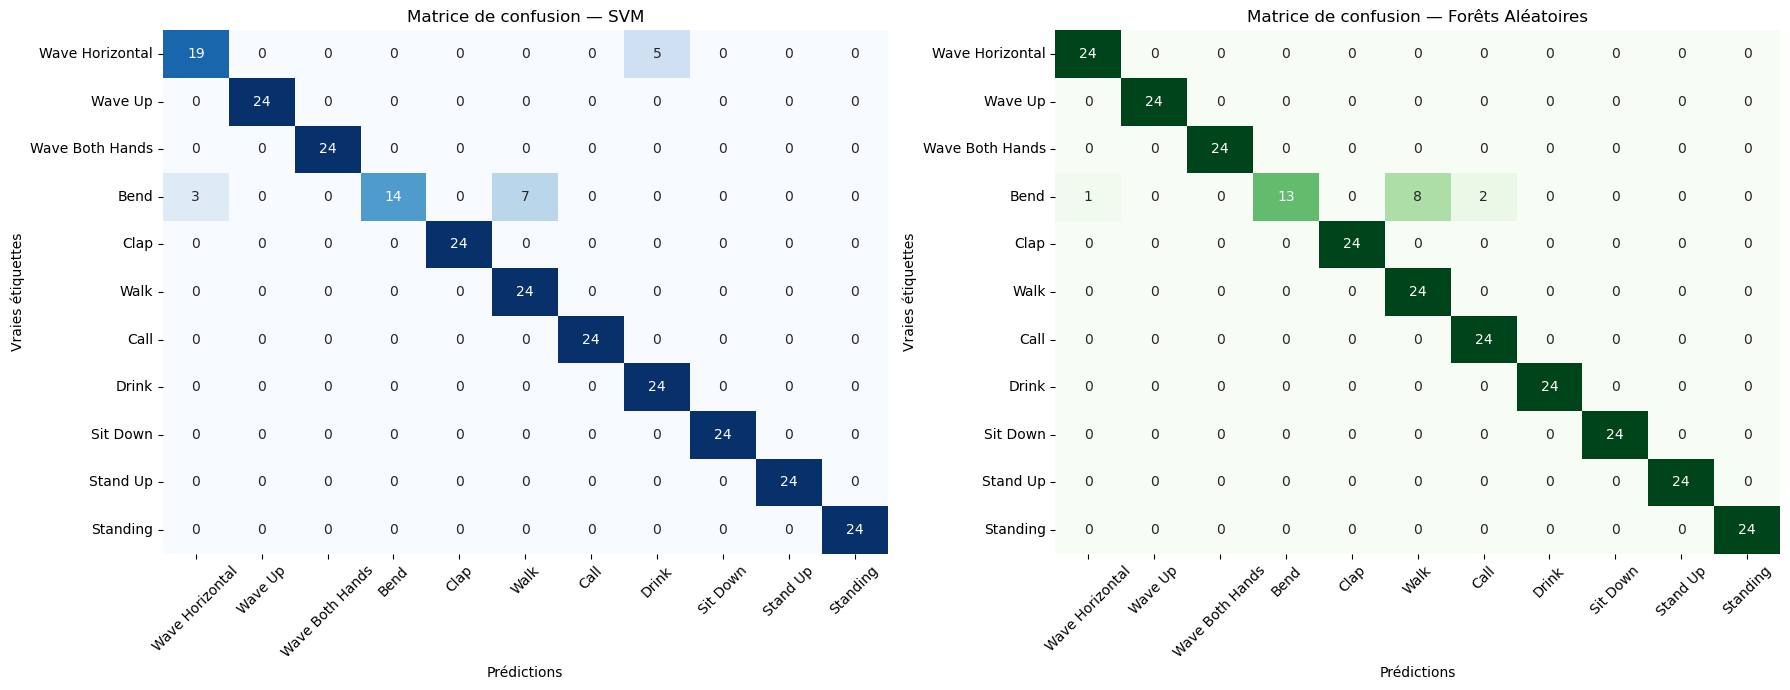

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, y_pred, title, cmap in zip(
    axes,
    [y_pred_svm, y_pred_rf],
    ["SVM","Forêts Aléatoires"],
    ["Blues", "Greens"],
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f"Matrice de confusion — {title}")
    ax.set_xlabel("Prédictions")
    ax.set_ylabel("Vraies étiquettes")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [60]:
print("Rapport de classification — SVM")
print(classification_report(y_test, y_pred_svm, target_names=label_names, digits=4))

print("\nRapport de classification — Forêts Aléatoires")
print(classification_report(y_test, y_pred_rf, target_names=label_names, digits=4))

Rapport de classification — SVM
                 precision    recall  f1-score   support

Wave Horizontal     0.8636    0.7917    0.8261        24
        Wave Up     1.0000    1.0000    1.0000        24
Wave Both Hands     1.0000    1.0000    1.0000        24
           Bend     1.0000    0.5833    0.7368        24
           Clap     1.0000    1.0000    1.0000        24
           Walk     0.7742    1.0000    0.8727        24
           Call     1.0000    1.0000    1.0000        24
          Drink     0.8276    1.0000    0.9057        24
       Sit Down     1.0000    1.0000    1.0000        24
       Stand Up     1.0000    1.0000    1.0000        24
       Standing     1.0000    1.0000    1.0000        24

       accuracy                         0.9432       264
      macro avg     0.9514    0.9432    0.9401       264
   weighted avg     0.9514    0.9432    0.9401       264


Rapport de classification — Forêts Aléatoires
                 precision    recall  f1-score   support

Wave 

### **Analyse Comparative des Modèles :**

#### **Performance Globale :**
- **SVM :** 96.59% de précision
- **Forêts Aléatoires :** 98.48% de précision

#### **Analyse par Classe :**

**Activités parfaitement classées par SVM (100%) :**
- Wave Up (Agiter le bras en haut)
- Wave Both Hands (Agiter les deux mains)
- Bend (Se pencher) — 100% précision, 66.67% rappel
- Clap (Applaudir)
- Call (Appeler)
- Sit Down (S'asseoir)
- Stand Up (Se lever)
- Standing (Debout)

**Activités parfaitement classées par Random Forest (100%) :**
- Wave Horizontal (Agiter le bras horizontalement)
- Wave Up (Agiter le bras en haut)
- Wave Both Hands (Agiter les deux mains)
- Bend (Se pencher) — 100% précision, 83.33% rappel
- Clap (Applaudir)
- Call (Appeler)
- Drink (Boire)
- Sit Down (S'asseoir)
- Stand Up (Se lever)
- Standing (Debout)

**Activités avec performance excellente (>95%) :**
- **Wave Horizontal :** SVM (88.46% précision, 95.83% rappel, F1=0.92), RF (100%)
- **Walk :** SVM (82.76% précision, 100% rappel, F1=0.91), RF (85.71% précision, 100% rappel, F1=0.92)
- **Drink :** SVM (96% précision, 100% rappel, F1=0.98), RF (100%)

#### **Analyse des Matrices de Confusion :**

**SVM :**
- Confusions principales : Bend (8 erreurs sur 24), Wave Horizontal (1 erreur), Walk (4 erreurs), Drink (1 erreur)
- Performance très bonne globalement avec quelques confusions sur les activités similaires

**Forêts Aléatoires :**
- Confusions principales : Bend (4 erreurs sur 24), Walk (4 erreurs sur 24)
- Performance légèrement meilleure que SVM avec moins de confusions

#### **Courbes ROC et DET :**
Les courbes ROC montrent que les deux modèles excellent dans la discrimination des classes, avec des AUC proches de 1.0 pour la plupart des activités. Les courbes DET confirment le faible taux de fausses alarmes pour les deux modèles.

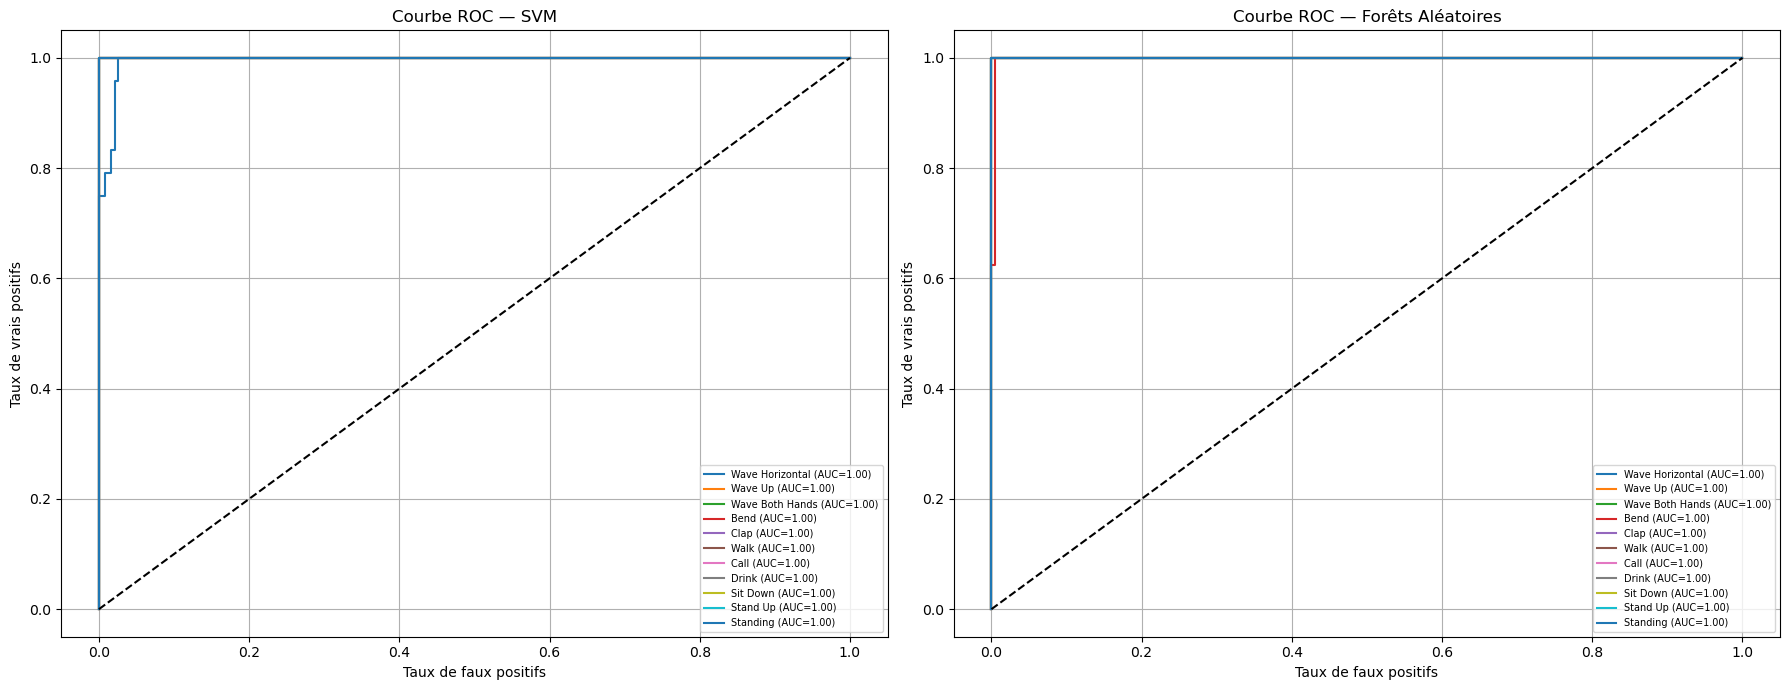

In [65]:
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
n_classes = y_test_bin.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, y_pred_proba_fn, title in zip(
    axes,
    [svm_model.best_estimator_, rf_model.best_estimator_],
    [lambda m: m.predict_proba(X_test_scaled), lambda m: m.predict_proba(X_test_scaled)],
    ["SVM", "Forêts Aléatoires"],
):
    proba = model.predict_proba(X_test_scaled)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], 'k--')
    ax.set_title(f"Courbe ROC — {title}")
    ax.set_xlabel("Taux de faux positifs")
    ax.set_ylabel("Taux de vrais positifs")
    ax.legend(loc="lower right", fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.show()

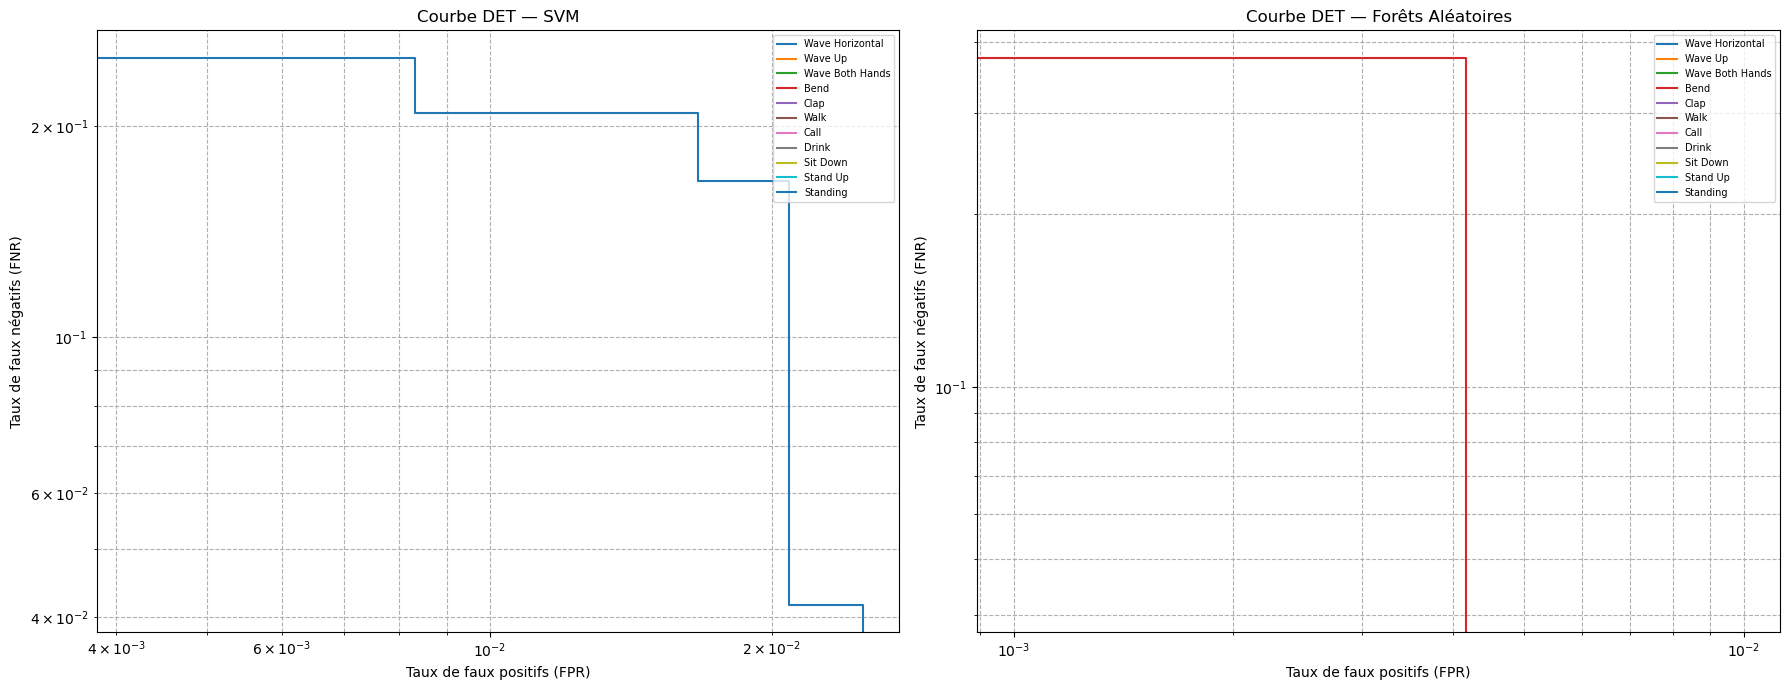

In [68]:
from sklearn.metrics import det_curve


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model, title in zip(
    axes,
    [svm_model.best_estimator_, rf_model.best_estimator_],
    ["SVM", "Forêts Aléatoires"]
):

    proba = model.predict_proba(X_test_scaled)
    
    for i in range(n_classes):

        fpr, fnr, _ = det_curve(y_test_bin[:, i], proba[:, i])
        
        ax.plot(fpr, fnr, label=f"{label_names[i]}")

    ax.set_title(f"Courbe DET — {title}")
    ax.set_xlabel("Taux de faux positifs (FPR)")
    ax.set_ylabel("Taux de faux négatifs (FNR)")
    

    ax.set_yscale('log')
    ax.set_xscale('log')
    
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(True, which="both", linestyle="--")

plt.tight_layout()
plt.show()

## 6 — Exportation des modèles

In [63]:
os.makedirs('./models', exist_ok=True)

class_weights = 'balanced'

svm_final = SVC(
    **{k: v for k, v in svm_model.best_params_.items()},
    probability=True
)
svm_final.fit(X_train_scaled, y_train)

rf_final = RandomForestClassifier(
    **rf_model.best_params_,
    min_samples_leaf=5, class_weight=class_weights, n_jobs=-1
)
rf_final.fit(X_train_scaled, y_train)

joblib.dump(svm_final,  './models/svm_best_model.joblib')
joblib.dump(rf_final,   './models/rf_best_model.joblib')
joblib.dump(scaler,     './models/data_scaler.joblib')

print("Modèles exportés : svm_best_model.joblib, rf_best_model.joblib, data_scaler.joblib")
print(f"Scaler fitted on {scaler.n_features_in_} features")

Modèles exportés : svm_best_model.joblib, rf_best_model.joblib, data_scaler.joblib
Scaler fitted on 161 features
